### get historic data

In [46]:
### get data
import time
import pandas as pd
import numpy as np
import talib.abstract as ta
import ccxt

exchange = ccxt.binanceusdm({
	'apiKey': '',
	'secret': '',
})
# get klines from start to present
def get_history(symbol, interval, start= None, limit = 1000):
	if start:
		start = exchange.parse8601(start)

	data = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=start, limit=limit) 
	lastBarActual = data[-1][0] # timestamp of last loaded bar
	# timestamp of current bar
	lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]
	# if lastBarActual != lastBarCurrent => pull the next 1000 bars
	while lastBarActual != lastBarCurrent:
		time.sleep(0.1)
		data += exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, since=lastBarActual, limit=limit)[1:]
		lastBarActual = data[-1][0]
		lastBarCurrent = exchange.fetch_ohlcv(symbol=symbol, timeframe=interval, limit=1)[-1][0]

	df = pd.DataFrame(data)
	df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
	df.date= pd.to_datetime(df.date, unit='ms')
	df.set_index('date', inplace=True)
	
	return df
df = get_history("ETHUSDT", '1h', start='2023-01-01T00:00:00Z')
price_columns = ['open', 'high', 'low', 'close']
for col in price_columns:
    df[col] = df[col].mask((df[col] <= 0) | (df[col] > df[col].quantile(0.999)), np.nan)
    df[col] = df[col].ffill()

### build factor

In [29]:
def rev_f(df, smooth_window=5):
# def rev_f(df, smooth_window=8, vol_window=21, long_vol_window=169):
        df['rsi_z'] = (df['rsi'] - df['rsi'].rolling(200).mean()) / df['rsi'].rolling(200).std()
        ret = df['close'].pct_change(1)
        raw_acc = ret.diff().abs()
        epsilon = 1e-6
        acc = raw_acc.ewm(span=smooth_window, adjust=False).mean() + epsilon
        # stable_volatility = ret_vol.clip(lower=vol_floor) + epsilon
        # normalized_acceleration = acc / stable_volatility
        # normalized_acceleration = normalized_acceleration.clip(-10, 10)
        # exhaustion_score = normalized_acceleration.ewm(span=score_window, adjust=False).mean()
        rev_f = (df['rsi_z'])/acc
        # rev_f = (df['rsi']-50)/np.log1p(1 / (abs(acc) + epsilon))
        return rev_f 

In [56]:
# origin factor
def calc_exhs(price_series, smooth_window=5, vol_window=21, long_vol_window=233, score_window=8):
        log_return = np.log(price_series / price_series.shift(1))
        raw_acceleration = log_return.diff()
        smoothed_acceleration = raw_acceleration.ewm(span=smooth_window, adjust=False).mean()
        return_volatility = log_return.ewm(span=vol_window, adjust=False).std()
        volatility_floor = return_volatility.ewm(span=long_vol_window, adjust=False).mean().mean() * 0.1
        epsilon = 1e-9
        stable_volatility = return_volatility.clip(lower=volatility_floor) + epsilon
        normalized_acceleration = smoothed_acceleration / stable_volatility
        normalized_acceleration = normalized_acceleration.clip(-10, 10)
        exhaustion_score = normalized_acceleration.ewm(span=score_window, adjust=False).mean()
        return exhaustion_score

In [59]:
def laguerre_filter(series, alpha=0.4):
    gamma = 1- alpha
    L0= L1= L2= L3= series.iloc[0]
    filt = []
    
    for p in series:
        L0_ = (1 - gamma) * p + gamma * L0
        L1_ = -gamma * L0_ + L0 + gamma * L1
        L2_ = -gamma * L1_ + L1 + gamma * L2
        L3_= -gamma * L2_ + L2 + gamma * L3
        filt.append(((L0_ + 2*L1_ + 2*L2_ + L3_) / 6))
        L0, L1, L2, L3 = L0_, L1_, L2_, L3_
    return pd.Series(filt, index=series.index)

In [60]:
# rev_f(bias_z, rsi)
df['lag_p'] = laguerre_filter(df['close'], 0.4)
df['bias'] = df['close']/df['lag_p']
df['rsi'] = ta.RSI(df, 14)
df['rsi50'] = ta.RSI(df, 14)-50
# bias.z_score()
df['bias_z'] = df['bias'].rolling(288).apply(lambda x: (x[-1]-x.mean())/x.std(), raw=False)
df['rsi_z'] = df['rsi50'].rolling(288).apply(lambda x: (x[-1]-x.mean())/x.std(), raw=False)
# syn
df['bias_rsi'] = -1*(0.6*df['bias_z'] + 0.4*df['rsi_z'])

df.tail(200)

C:\Users\xlfin\AppData\Local\Temp\ipykernel_27232\814582343.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['bias_z'] = df['bias'].rolling(288).apply(lambda x: (x[-1]-x.mean())/x.std(), raw=False)
C:\Users\xlfin\AppData\Local\Temp\ipykernel_27232\814582343.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['rsi_z'] = df['rsi50'].rolling(288).apply(lambda x: (x[-1]-x.mean())/x.std(), raw=False)


,open,high,low,close,volume,ema55,bias,rsi,rsi50,bias_z,rsi_z,bias_rsi,lag_p
date,,,,,,,,,,,,,
2025-10-26 23:00:00,4158.55,4177.71,4146.00,4156.37,157889.400,3989.623188,1.023984,79.480303,29.480303,1.682821,2.582942,-2.042870,4059.016797
2025-10-27 00:00:00,4156.36,4188.00,4145.27,4168.64,195837.385,3996.016646,1.024973,80.617523,30.617523,1.742038,2.645907,-2.103586,4067.073804
2025-10-27 01:00:00,4168.64,4207.95,4165.22,4190.34,209291.355,4002.956766,1.027928,82.468081,32.468081,1.932318,2.765710,-2.265675,4076.493297
2025-10-27 02:00:00,4190.34,4217.60,4181.83,4203.60,179708.262,4010.122595,1.028349,83.504482,33.504482,1.944393,2.809597,-2.290474,4087.718580
2025-10-27 03:00:00,4203.60,4225.14,4198.50,4203.21,112705.550,4017.018574,1.025124,83.348419,33.348419,1.706188,2.748622,-2.123161,4100.196999
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-04 02:00:00,3642.85,3647.35,3616.56,3624.51,106958.755,3743.948189,0.998090,40.630119,-9.369881,-0.052656,-0.783825,0.345123,3631.446847
2025-11-04 03:00:00,3624.50,3650.00,3618.80,3640.90,105898.379,3740.267897,1.003886,43.654720,-6.345280,0.388739,-0.536380,-0.018692,3626.807670
2025-11-04 04:00:00,3640.91,3646.80,3620.00,3623.85,93995.371,3736.110115,0.999981,41.297728,-8.702272,0.094169,-0.724830,0.233431,3623.919668


In [75]:
(df.bias_rsi < -1).sum()

3211

### test factor

### test

In [63]:
tdf = df.copy()
tdf['ret_2'] = tdf['close'].shift(-2)/tdf['close']-1
tdf['ret_5'] = tdf['close'].shift(-5)/tdf['close']-1
tdf['ret_21'] = tdf['close'].shift(-21)/tdf['close']-1
# tdf['rev_f_q'] = pd.qcut(df['rev_f'], 10, labels=False)

In [77]:
# IC test
ic = tdf[['bias_rsi', 'ret_2']].corr(method='spearman').iloc[0, 1]
print(f"IC(全样本): {ic:.4f}")

IC(全样本): 0.0419


q
0.0    0.000531
1.0    0.000304
2.0    0.000228
3.0    0.000325
4.0   -0.000155
5.0   -0.000043
6.0    0.000106
7.0   -0.000184
8.0    0.000005
9.0    0.000055
Name: ret_2, dtype: float64


<Axes: title={'center': 'rev_f 分组未来收益'}, xlabel='q'>

c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: 

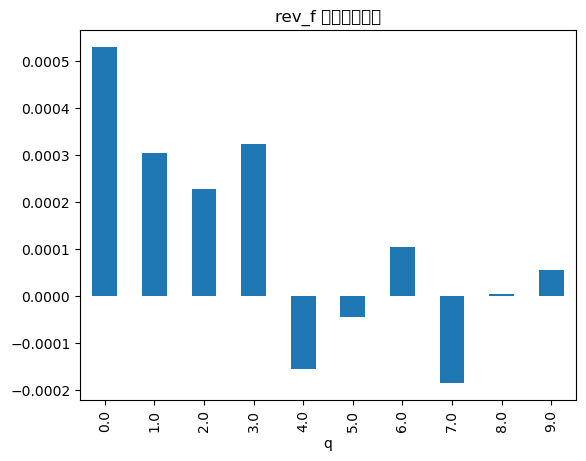

In [78]:
# 分箱测试
tdf['q'] = pd.qcut(tdf['bias_rsi'], 10, labels=False, duplicates='drop')

group_ret = tdf.groupby('q')['ret_2'].mean()
print(group_ret)

# 可视化收益分布
group_ret.plot(kind='bar', title='rev_f 分组未来收益')

In [79]:
# T test
import scipy.stats as st

high = tdf.loc[tdf['q'] >= 8, 'ret_2'].dropna()
low  = tdf.loc[tdf['q'] <= 1, 'ret_2'].dropna()

t, p = st.ttest_ind(high, low, equal_var=False)
print(f"T-test 高低组差异: T={t:.4f}, P={p:.4f}")

T-test 高低组差异: T=-1.8132, P=0.0698


q
0.0   -0.000758
1.0   -0.000183
2.0    0.000364
3.0    0.000420
4.0    0.000068
5.0    0.000015
6.0    0.000153
7.0   -0.000103
8.0    0.000107
9.0    0.001243
Name: ret_5, dtype: float64


<Axes: title={'center': 'rev_f 分组未来收益'}, xlabel='q'>

c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: 

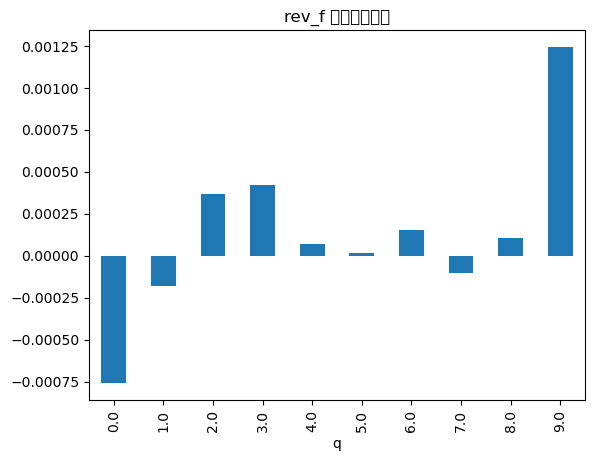

In [47]:
# 分箱测试
# df['q'] = pd.qcut(df['rev_f'], 10, labels=False, duplicates='drop')
df['q'] = pd.qcut(df['rsi50'], 10, labels=False, duplicates='drop')

group_ret = df.groupby('q')['ret_5'].mean()
print(group_ret)

# 可视化收益分布
group_ret.plot(kind='bar', title='rev_f 分组未来收益')



In [49]:
# T test
import scipy.stats as st

high = df.loc[df['q'] > 8, 'ret_5'].dropna()
low  = df.loc[df['q'] < 2, 'ret_5'].dropna()

t, p = st.ttest_ind(high, low, equal_var=False)
print(f"T-test 高低组差异: T={t:.4f}, P={p:.4f}")


T-test 高低组差异: T=4.7271, P=0.0000


### long-term rsi

In [74]:
def laguerre_filter(series, alpha=0.4):
    gamma = 1- alpha
    L0= L1= L2= L3= series.iloc[0]
    filt = []
    
    for p in series:
        L0_ = (1 - gamma) * p + gamma * L0
        L1_ = -gamma * L0_ + L0 + gamma * L1
        L2_ = -gamma * L1_ + L1 + gamma * L2
        L3_= -gamma * L2_ + L2 + gamma * L3
        filt.append(((L0_ + 2*L1_ + 2*L2_ + L3_) / 6))
        L0, L1, L2, L3 = L0_, L1_, L2_, L3_
    return pd.Series(filt, index=series.index)
df['lag_p'] = laguerre_filter(df['close'], alpha=0.3333) 
df['a_'] = df.lag_p.diff().diff() 
df['a_z'] = (df['a_'] - df['a_'].rolling(500).mean()) / df['a_'].rolling(500).std()

<Axes: >

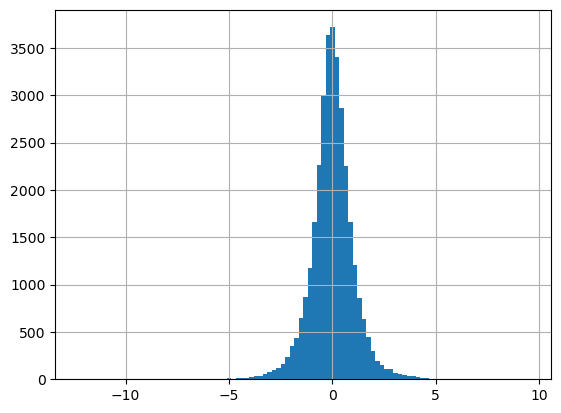

In [76]:
df.a_z.hist(bins=100)

In [59]:
# IC test
# ic = df[['rev_f', 'ret_21']].corr(method='spearman').iloc[0, 1]
ic = df[['score', 'ret_5']].corr(method='spearman').iloc[0, 1]
print(f"IC(全样本): {ic:.4f}")

IC(全样本): -0.0198


In [63]:
# T test
import scipy.stats as st

high = df.loc[df['q'] >= 8, 'ret_5'].dropna()
low  = df.loc[df['q'] <= 2, 'ret_5'].dropna()

t, p = st.ttest_ind(high, low, equal_var=False)
print(f"T-test 高低组差异: T={t:.4f}, P={p:.4f}")

T-test 高低组差异: T=-0.1524, P=0.8788


In [62]:
df.tail(20)

,open,high,low,close,volume,rsi,rev_f,ret_5,ret_8,q,rsi_z,ret_21,rsi50,trend_strength,rsi21,rsi2150,score
date,,,,,,,,,,,,,,,,,
2025-11-02 14:00:00,3866.46,3871.50,3837.04,3851.40,140088.427,41.805521,-206.353157,0.000774,0.000517,0.0,-0.786830,NaN,-8.194479,0.025198,45.227142,-4.772858,-0.103643
2025-11-02 15:00:00,3851.40,3869.91,3844.01,3851.63,74384.643,41.896847,-200.447479,0.001444,0.013805,3.0,-0.773848,NaN,-8.103153,-0.007065,45.281289,-4.718711,-0.035707
2025-11-02 16:00:00,3851.63,3863.58,3838.23,3862.75,90327.630,46.285783,-117.274063,-0.000831,0.000142,8.0,-0.412397,NaN,-3.714217,-0.002851,47.896128,-2.103872,0.061591
2025-11-02 17:00:00,3862.75,3862.76,3847.85,3857.70,31239.354,44.636772,-144.683643,-0.001117,-0.005843,5.0,-0.541527,NaN,-5.363228,0.000499,46.829040,-3.170960,0.018168
2025-11-02 18:00:00,3857.70,3865.89,3853.52,3862.44,27193.756,46.561212,-114.198888,0.010967,-0.016842,7.0,-0.381528,NaN,-3.438788,0.066859,47.971439,-2.028561,0.051312
2025-11-02 19:00:00,3862.44,3862.99,3840.93,3854.38,48063.536,43.774781,-180.860208,0.002314,-0.031043,4.0,-0.602765,NaN,-6.225219,0.044974,46.199194,-3.800806,-0.012493
2025-11-02 20:00:00,3854.38,3858.19,3846.00,3857.19,19203.337,45.010333,-157.243477,-0.005711,-0.029148,6.0,-0.497012,NaN,-4.989667,0.010917,46.917081,-3.082919,0.022942
2025-11-02 21:00:00,3857.19,3867.45,3848.39,3859.54,34074.826,46.077533,-189.438523,-0.016103,-0.033499,6.0,-0.406810,NaN,-3.922467,-0.042962,47.531853,-2.468147,0.037519
2025-11-02 22:00:00,3859.54,3862.08,3842.41,3853.39,36082.148,43.687969,-275.330329,-0.030794,-0.035392,4.0,-0.596421,NaN,-6.312031,-0.008929,46.065850,-3.934150,-0.015755


q
0.0    0.000185
1.0    0.000187
2.0    0.000324
3.0    0.000107
4.0    0.000057
5.0   -0.000371
6.0    0.000305
7.0    0.000155
8.0    0.000190
9.0    0.000193
Name: ret_5, dtype: float64


<Axes: title={'center': 'rev_f 分组未来收益'}, xlabel='q'>

c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\xlfin\anaconda3\lib\site-packages\IPython\core\events.py:89: 

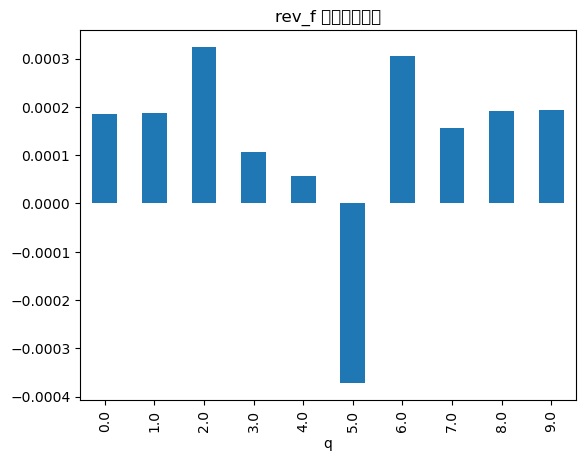

In [60]:
# 分箱测试
# df['q'] = pd.qcut(df['rev_f'], 10, labels=False, duplicates='drop')
df['q'] = pd.qcut(df['score'], 10, labels=False, duplicates='drop')

group_ret = df.groupby('q')['ret_5'].mean()
print(group_ret)

# 可视化收益分布
group_ret.plot(kind='bar', title='rev_f 分组未来收益')
